In [1]:
# Add src to path to allow importing net_epistemology without installing the package
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [2]:
from net_epistemology.utils.imports import *
from net_epistemology.core.vectorized_model import VectorizedModel
import matplotlib.pyplot as plt

In [3]:
# Save and load pud_final as JSON
import json
from networkx.readwrite import json_graph
from pathlib import Path

JSON_PATH = Path("../data/empirical_networks/pud_final.json")

# Save to JSON
def save_network_json(G, path):
    data = json_graph.node_link_data(G)
    with open(path, "w") as f:
        json.dump(data, f)
    print(f"Saved network to {path}")

# Load from JSON
def load_network_json(path):
    with open(path, "r") as f:
        data = json.load(f)
    # Fix for networkx expecting 'edges' instead of 'links' or vice-versa
    if "links" in data and "edges" not in data:
        data["edges"] = data["links"]
    G = json_graph.node_link_graph(data)
    print(f"Loaded network from {path}")
    return G

# Example usage:
# save_network_json(pud_final, JSON_PATH)
my_network = load_network_json(JSON_PATH)

Loaded network from ../data/empirical_networks/pud_final.json


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/.venv/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


In [4]:
# n_agents = 1000
# my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

## Try with Bayes Agent (Vectorized)

In [5]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=50000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

100%|██████████| 50000/50000 [00:16<00:00, 3031.11it/s]


steps:  50000
conclusion:  0.5
conclusion core 0.7205882352941176


,0,1,2,3,4,5,6,7,8,9,...,302,303,304,305,306,307,308,309,310,311
0,0.474341,0.024322,0.867759,0.826639,0.586833,0.668162,0.546451,0.717227,0.775579,0.373561,...,0.152316,0.949500,0.419491,0.42632,0.495426,0.388562,0.406733,0.628872,0.730803,0.680961
1,0.474341,0.024513,0.866838,0.827782,0.590707,0.662819,0.558319,0.705732,0.772781,0.371691,...,0.152316,0.948727,0.421440,0.42632,0.495426,0.388562,0.406733,0.625130,0.732373,0.684427
2,0.474341,0.024322,0.867759,0.826639,0.584892,0.664605,0.564229,0.709044,0.772781,0.373561,...,0.151286,0.950262,0.423392,0.42632,0.495426,0.388562,0.406733,0.625130,0.733939,0.684427


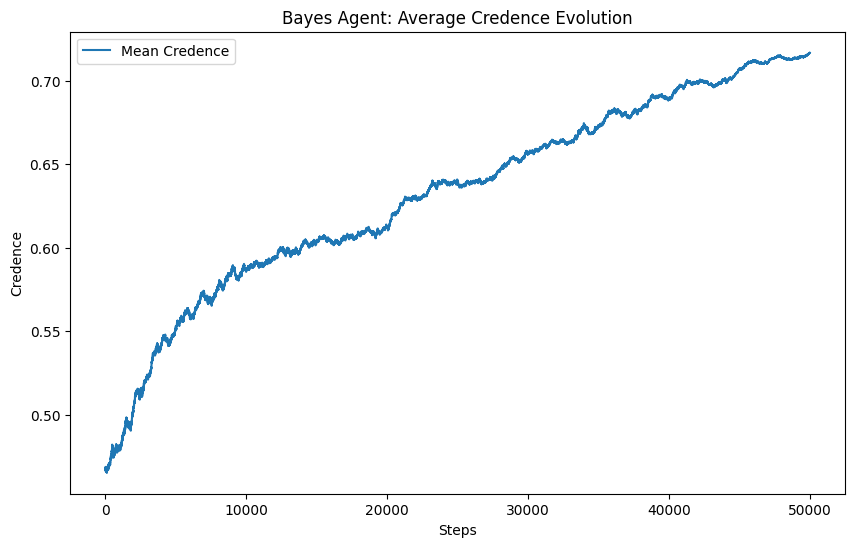

In [6]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [7]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

100%|██████████| 10000/10000 [00:05<00:00, 1980.72it/s]


steps:  10000
conclusion:  0.6378205128205128


,0,1,2,3,4,5,6,7,8,9,...,302,303,304,305,306,307,308,309,310,311
0,"[0.8435673900012107, 0.7353821320187879]","[0.8099551739153604, 0.9920432142697961]","[0.37104436678516906, 1.966126324346943e-05]","[0.6399649596665741, 0.330213975271984]","[0.9999968910880016, 0.9050965318230627]","[0.6433885383406978, 0.8387382887233938]","[0.46730369553028756, 3.0641164975825093e-06]","[0.38263280093089547, 0.17627000359163436]","[0.32358990515690456, 0.8659650282844614]","[0.344438524690663, 0.055623351297303225]",...,"[0.43708495572778844, 0.6618375803028618]","[0.6504410546331825, 0.7423709216263039]","[0.10212804221872426, 0.45781003599614933]","[0.29718500180629326, 0.2680971792765563]","[0.9022806328433521, 0.8621030111248257]","[0.917182883238572, 0.17696674408792082]","[0.5548728704215644, 0.07067051617227256]","[0.2384448360324359, 0.035399766199149967]","[0.40565167924101186, 0.9999999999995797]","[0.3371797341422135, 0.8076041470784938]"
1,"[0.6192843821752173, 0.7830571016550847]","[0.8529357519887522, 0.4193925154695136]","[0.28698260107940426, 0.0006691314920612221]","[0.5255043785160035, 0.7463882043288231]","[0.7254353902135703, 0.9868609692093252]","[0.3764858066860244, 0.5528383171306752]","[0.48107559426328306, 0.4073297597881888]","[0.5323402954353428, 0.44972207147024956]","[0.4584599453887676, 0.5077695385717292]","[0.41732160513589434, 0.43381445173503935]",...,"[0.3043161520377596, 0.37144799354511]","[0.2543877134458414, 0.6749645338451565]","[0.48339291064953177, 0.5384293737179796]","[0.5847213540839649, 0.310836070705067]","[0.5218936328794141, 0.5353993330671735]","[0.5766748382531041, 0.6073653814612446]","[0.43632561945247555, 0.34900768737675003]","[0.32604379300734543, 0.0050125517625879586]","[0.28755662083935635, 0.542326128899233]","[0.39851281849596104, 0.5390674968338216]"
2,"[0.7073724919899976, 0.5189499307314165]","[0.4566416373757685, 0.5009785627754276]","[0.19138977237444624, 0.00036189266126233384]","[0.3435629759541923, 0.6843709459410104]","[0.522756988960293, 0.2885448921487207]","[0.46533225991991994, 0.5824682391891698]","[0.5566825414968067, 0.3172355522899703]","[0.5617536571191382, 0.4608025386503334]","[0.7157135396364268, 0.4462872204750493]","[0.3833100788856773, 0.44307972684543073]",...,"[0.24856551946852007, 0.6476465420462201]","[0.3485483034372379, 0.46801937914034153]","[0.49460497020068606, 0.529211471558543]","[0.7101080531130678, 0.4336406228230316]","[0.6396921876344643, 0.4066028339478414]","[0.5160271938822465, 0.5932922381778185]","[0.17734571319567896, 0.20028098960200685]","[0.30845094917798865, 0.35376259736312576]","[0.6866098251068387, 0.571290702952698]","[0.5274833541789552, 0.36337430955254524]"


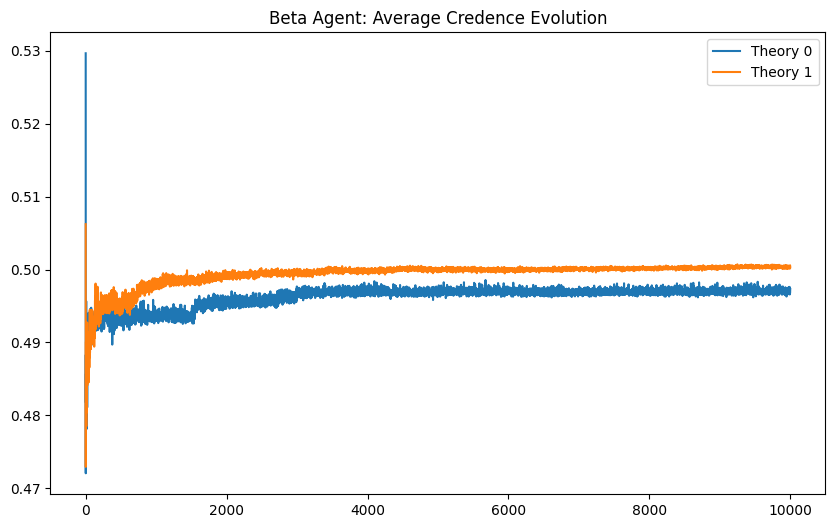

In [8]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

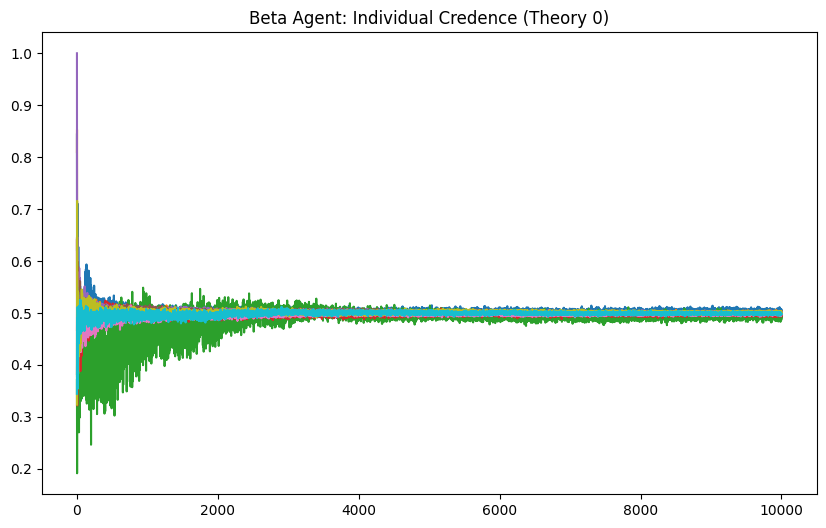

In [9]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()